# Lab Assignment 1 — ANN & DL

**COMSATS University Islamabad**  
Department of Computer Science

- **Name:** Shafi
- **Registration No.:** SP24-BAI-047
- **Class:** BSAI-6
- **Subject:** ANN & DL
- **Marks:** 10

---

**Contents**

| Task | Topic |
|---|---|
| Task 01 | McCulloch–Pitts neuron and logic gates |
| Task 02 | Perceptron, decision boundaries, linear separability |
| Task 03 | 2-layer MLP from scratch (NumPy) and the XOR problem |
| Task 04 | Weight initialization schemes |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

# Task 01

McCulloch–Pitts (M-P) neuron and logic gates.

## Task 1.1

**Apply the McCulloch–Pitts neural model to solve logical gates.**

The M-P neuron takes binary inputs $x_i \in \{0, 1\}$ and has fixed weights $w_i$ and a threshold $\theta$.

$$s = \sum_{i} w_i x_i \qquad\qquad y = \begin{cases} 1 & \text{if } s \ge \theta \\ 0 & \text{otherwise} \end{cases}$$

**Design recipe for a gate**

1. Write the truth table of the gate.
2. For every row, write the inequality that the weighted sum must satisfy ($s \ge \theta$ for output 1, $s < \theta$ for output 0).
3. Pick weights and a threshold that satisfy all inequalities at once.

## Task 1.2

**Implement a generic M-P neuron function `mp_neuron(inputs, weights, threshold)`.**

In [2]:
def mp_neuron(inputs, weights, threshold):
    # McCulloch-Pitts neuron: fires (returns 1) when the weighted sum reaches the threshold
    s = np.dot(inputs, weights)
    return int(s >= threshold)


# quick sanity check: weights (1, 1) with threshold 2 should behave like AND
print(mp_neuron([1, 1], [1, 1], 2))   # expected 1
print(mp_neuron([1, 0], [1, 1], 2))   # expected 0

1
0


## Task 1.3

**Realize the logic gates with the M-P neuron by manually choosing weights and threshold (with derivation).**

### AND gate (2-input)

| $x_1$ | $x_2$ | AND | Condition |
|---|---|---|---|
| 0 | 0 | 0 | $0 < \theta$ |
| 0 | 1 | 0 | $w_2 < \theta$ |
| 1 | 0 | 0 | $w_1 < \theta$ |
| 1 | 1 | 1 | $w_1 + w_2 \ge \theta$ |

Try $w_1 = w_2 = 1$. The conditions become $0 < \theta$, $1 < \theta$ and $2 \ge \theta$, so $1 < \theta \le 2$.

**Choice:** $w_1 = 1,\ w_2 = 1,\ \theta = 2$.

### OR gate (2-input)

| $x_1$ | $x_2$ | OR | Condition |
|---|---|---|---|
| 0 | 0 | 0 | $0 < \theta$ |
| 0 | 1 | 1 | $w_2 \ge \theta$ |
| 1 | 0 | 1 | $w_1 \ge \theta$ |
| 1 | 1 | 1 | $w_1 + w_2 \ge \theta$ |

Try $w_1 = w_2 = 1$. The conditions become $0 < \theta$, $1 \ge \theta$ and $2 \ge \theta$, so $0 < \theta \le 1$.

**Choice:** $w_1 = 1,\ w_2 = 1,\ \theta = 1$.

### NOT gate (1-input, negative weight)

| $x$ | NOT | Condition |
|---|---|---|
| 0 | 1 | $0 \ge \theta$ |
| 1 | 0 | $w < \theta$ |

The first row forces $\theta \le 0$. Take $\theta = 0$, then the second row needs $w < 0$, so a **negative weight** is required.

**Choice:** $w = -1,\ \theta = 0$.  
Check: $x=0 \Rightarrow s = 0 \ge 0 \Rightarrow 1$; $x=1 \Rightarrow s = -1 < 0 \Rightarrow 0$.

### AND gate for 3 inputs

The output must be 1 only for $(1,1,1)$. With $w_1 = w_2 = w_3 = 1$:

- Any combination with at most two 1s gives $s \le 2$, so we need $\theta > 2$.
- $(1,1,1)$ gives $s = 3$, so we need $3 \ge \theta$.

Hence $2 < \theta \le 3$.

**Choice:** $w_1 = w_2 = w_3 = 1,\ \theta = 3$.

In [3]:
GATES = {
    "AND (2-input)": dict(weights=[1, 1],    threshold=2, expected=lambda x: int(x[0] and x[1])),
    "OR (2-input)":  dict(weights=[1, 1],    threshold=1, expected=lambda x: int(x[0] or x[1])),
    "NOT (1-input)": dict(weights=[-1],      threshold=0, expected=lambda x: int(not x[0])),
    "AND (3-input)": dict(weights=[1, 1, 1], threshold=3, expected=lambda x: int(all(x))),
}

# verify each hand-designed gate against the true logic function
for name, g in GATES.items():
    for x in product([0, 1], repeat=len(g["weights"])):
        assert mp_neuron(x, g["weights"], g["threshold"]) == g["expected"](x), (name, x)
    print(f"{name:15s} weights={g['weights']}  threshold={g['threshold']}  -> verified")

AND (2-input)   weights=[1, 1]  threshold=2  -> verified
OR (2-input)    weights=[1, 1]  threshold=1  -> verified
NOT (1-input)   weights=[-1]  threshold=0  -> verified
AND (3-input)   weights=[1, 1, 1]  threshold=3  -> verified


## Task 1.4

**Attempt to realize the XOR gate using a single M-P neuron.**

Truth table conditions for XOR:

| $x_1$ | $x_2$ | XOR | Condition |
|---|---|---|---|
| 0 | 0 | 0 | $0 < \theta$ |
| 0 | 1 | 1 | $w_2 \ge \theta$ |
| 1 | 0 | 1 | $w_1 \ge \theta$ |
| 1 | 1 | 0 | $w_1 + w_2 < \theta$ |

From the first row $\theta > 0$. Adding the two middle rows gives $w_1 + w_2 \ge 2\theta > \theta$, which contradicts the last row ($w_1 + w_2 < \theta$).

**No weights and threshold exist, so XOR cannot be realized by a single M-P neuron.**
Below, a brute-force search over a grid of weights and thresholds confirms this numerically.

In [4]:
def search_single_neuron(target_fn, n_inputs=2, grid=np.arange(-3, 3.5, 0.5)):
    inputs = list(product([0, 1], repeat=n_inputs))
    solutions = []
    for w in product(grid, repeat=n_inputs):
        for th in grid:
            if all(mp_neuron(x, w, th) == target_fn(x) for x in inputs):
                solutions.append((w, th))
    return solutions


targets = {
    "AND": lambda x: int(x[0] and x[1]),
    "OR":  lambda x: int(x[0] or x[1]),
    "XOR": lambda x: int(x[0] != x[1]),
}

for name, fn in targets.items():
    sols = search_single_neuron(fn)
    print(f"{name:3s}: {len(sols):4d} (weights, threshold) combinations work")

AND:   35 (weights, threshold) combinations work
OR :   91 (weights, threshold) combinations work
XOR:    0 (weights, threshold) combinations work


**Bonus:** XOR becomes possible with a *network* of M-P neurons (two layers), since

$$x_1 \oplus x_2 = (x_1 \lor x_2) \land \lnot (x_1 \land x_2)$$

- Hidden neuron 1: OR, $w = (1,1),\ \theta = 1$
- Hidden neuron 2: AND, $w = (1,1),\ \theta = 2$
- Output neuron: $h_1 \land \lnot h_2$, $w = (1,-1),\ \theta = 1$

In [5]:
def xor_two_layer(x1, x2):
    h1 = mp_neuron([x1, x2], [1, 1], 1)       # OR
    h2 = mp_neuron([x1, x2], [1, 1], 2)       # AND
    return mp_neuron([h1, h2], [1, -1], 1)    # h1 AND (NOT h2)


for x in product([0, 1], repeat=2):
    print(x, "->", xor_two_layer(*x))

(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


## Task 1.5

**Print a truth table for each gate showing inputs, weighted sum, and output.**

In [6]:
def truth_table(name, weights, threshold, expected_fn=None):
    n = len(weights)
    rows = []
    for x in product([0, 1], repeat=n):
        row = {f"x{i + 1}": xi for i, xi in enumerate(x)}
        row["weighted sum"] = np.dot(x, weights)
        row["output"] = mp_neuron(x, weights, threshold)
        if expected_fn is not None:
            row["expected"] = expected_fn(x)
            row["correct"] = "yes" if row["output"] == row["expected"] else "NO"
        rows.append(row)
    print(f"{name}   weights = {weights},  threshold = {threshold}")
    print(pd.DataFrame(rows).to_string(index=False))
    print()


for name, g in GATES.items():
    truth_table(name, g["weights"], g["threshold"], g["expected"])

AND (2-input)   weights = [1, 1],  threshold = 2
 x1  x2  weighted sum  output  expected correct
  0   0             0       0         0     yes
  0   1             1       0         0     yes
  1   0             1       0         0     yes
  1   1             2       1         1     yes

OR (2-input)   weights = [1, 1],  threshold = 1
 x1  x2  weighted sum  output  expected correct
  0   0             0       0         0     yes
  0   1             1       1         1     yes
  1   0             1       1         1     yes
  1   1             2       1         1     yes

NOT (1-input)   weights = [-1],  threshold = 0
 x1  weighted sum  output  expected correct
  0             0       1         1     yes
  1            -1       0         0     yes

AND (3-input)   weights = [1, 1, 1],  threshold = 3
 x1  x2  x3  weighted sum  output  expected correct
  0   0   0             0       0         0     yes
  0   0   1             1       0         0     yes
  0   1   0             1       0

Truth table for the **XOR attempt** with a single M-P neuron. The best a single neuron can do is match 3 of the 4 rows
(here $w = (1,1),\ \theta = 1$ gives OR), so at least one row is always wrong.

In [7]:
truth_table("XOR (single neuron attempt)", [1, 1], 1, targets["XOR"])

XOR (single neuron attempt)   weights = [1, 1],  threshold = 1
 x1  x2  weighted sum  output  expected correct
  0   0             0       0         0     yes
  0   1             1       1         1     yes
  1   0             1       1         1     yes
  1   1             2       1         0      NO



# Task 02

Perceptron, decision boundaries and linear separability.

## Task 2.1

**Implement a `Perceptron` class with `fit(X, y, epochs, lr)` and `predict(X)` using a step activation function.**

For every training sample the perceptron computes $\hat{y} = \text{step}(\mathbf{w}\cdot\mathbf{x} + b)$ and applies the learning rule

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\,(y - \hat{y})\,\mathbf{x} \qquad\qquad b \leftarrow b + \eta\,(y - \hat{y})$$

The number of misclassified samples (weight updates) in each epoch is stored in `errors_`.

In [8]:
def step(z):
    return np.where(z >= 0, 1, 0)


class Perceptron:
    def __init__(self):
        self.w = None
        self.b = 0.0
        self.errors_ = []

    def fit(self, X, y, epochs=20, lr=0.1):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        self.errors_ = []
        for _ in range(epochs):
            errors = 0
            for xi, target in zip(X, y):
                pred = step(np.dot(xi, self.w) + self.b)
                delta = lr * (target - pred)
                self.w += delta * xi
                self.b += delta
                errors += int(delta != 0)
            self.errors_.append(errors)
        return self

    def predict(self, X):
        return step(np.dot(np.asarray(X, dtype=float), self.w) + self.b)

## Task 2.2

**Train on the AND and OR truth tables and plot the decision boundary (2D plot with the separating line).**

In [9]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

p_and = Perceptron().fit(X, y_and, epochs=20, lr=0.1)
p_or = Perceptron().fit(X, y_or, epochs=20, lr=0.1)

for name, p, y in [("AND", p_and, y_and), ("OR", p_or, y_or)]:
    print(f"{name}: w = {p.w}, b = {p.b:.2f}, predictions = {p.predict(X)}, target = {y}")

AND: w = [0.2 0.1], b = -0.20, predictions = [0 0 0 1], target = [0 0 0 1]
OR: w = [0.1 0.1], b = -0.10, predictions = [0 1 1 1], target = [0 1 1 1]


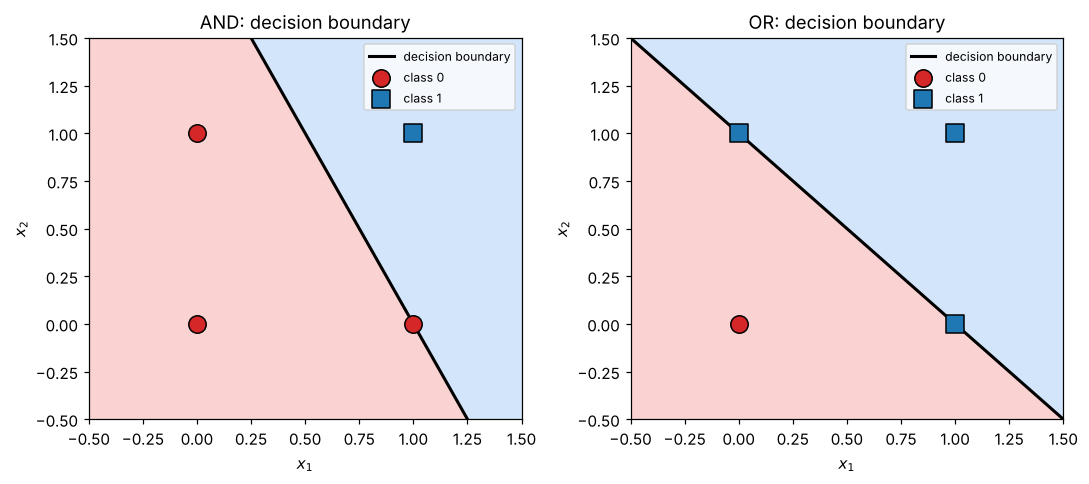

In [10]:
def plot_perceptron_boundary(model, X, y, ax, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#f8b4b4", "#b4d4f8"], alpha=0.6)

    # separating line: w1*x1 + w2*x2 + b = 0
    w1, w2 = model.w
    xs = np.linspace(-0.5, 1.5, 100)
    if w2 != 0:
        ax.plot(xs, -(w1 * xs + model.b) / w2, "k-", lw=2, label="decision boundary")
    elif w1 != 0:
        ax.axvline(-model.b / w1, color="k", lw=2, label="decision boundary")

    for cls, marker, color in [(0, "o", "tab:red"), (1, "s", "tab:blue")]:
        ax.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=130, c=color,
                   edgecolors="k", label=f"class {cls}", zorder=3)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_perceptron_boundary(p_and, X, y_and, axes[0], "AND: decision boundary")
plot_perceptron_boundary(p_or, X, y_or, axes[1], "OR: decision boundary")
plt.tight_layout()
plt.show()

## Task 2.3

**Plot the number of misclassifications per epoch to show convergence.**

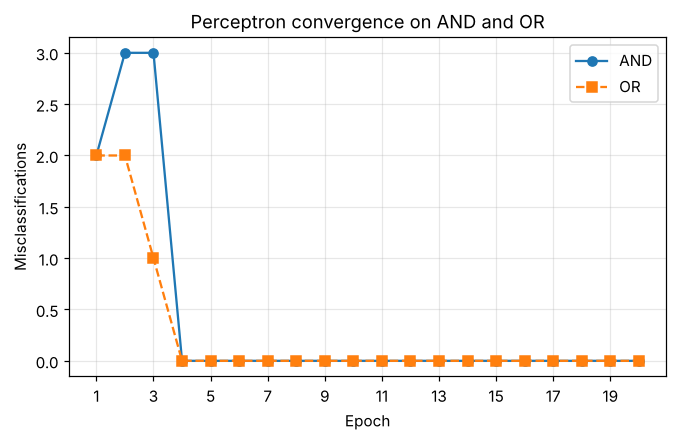

AND: errors per epoch = [2, 3, 3, 0, 0] ... -> reaches 0 errors at epoch 4
OR: errors per epoch = [2, 2, 1, 0, 0] ... -> reaches 0 errors at epoch 4


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(p_and.errors_) + 1), p_and.errors_, "o-", label="AND")
ax.plot(range(1, len(p_or.errors_) + 1), p_or.errors_, "s--", label="OR")
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassifications")
ax.set_title("Perceptron convergence on AND and OR")
ax.set_xticks(range(1, 21, 2))
ax.legend()
ax.grid(alpha=0.3)
plt.show()

for name, p in [("AND", p_and), ("OR", p_or)]:
    first_zero = next(i for i, e in enumerate(p.errors_, 1) if e == 0)
    print(f"{name}: errors per epoch = {p.errors_[:first_zero + 1]} ... -> reaches 0 errors at epoch {first_zero}")

## Task 2.4

**Attempt to train the same perceptron on the XOR truth table.**

The perceptron is trained for 50 epochs. Below we plot the error curve, the final decision boundary, and the XOR points together with several candidate lines.

errors per epoch (first 20): [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
minimum errors in any epoch: 3
final predictions: [1 1 0 0]  target: [0 1 1 0]


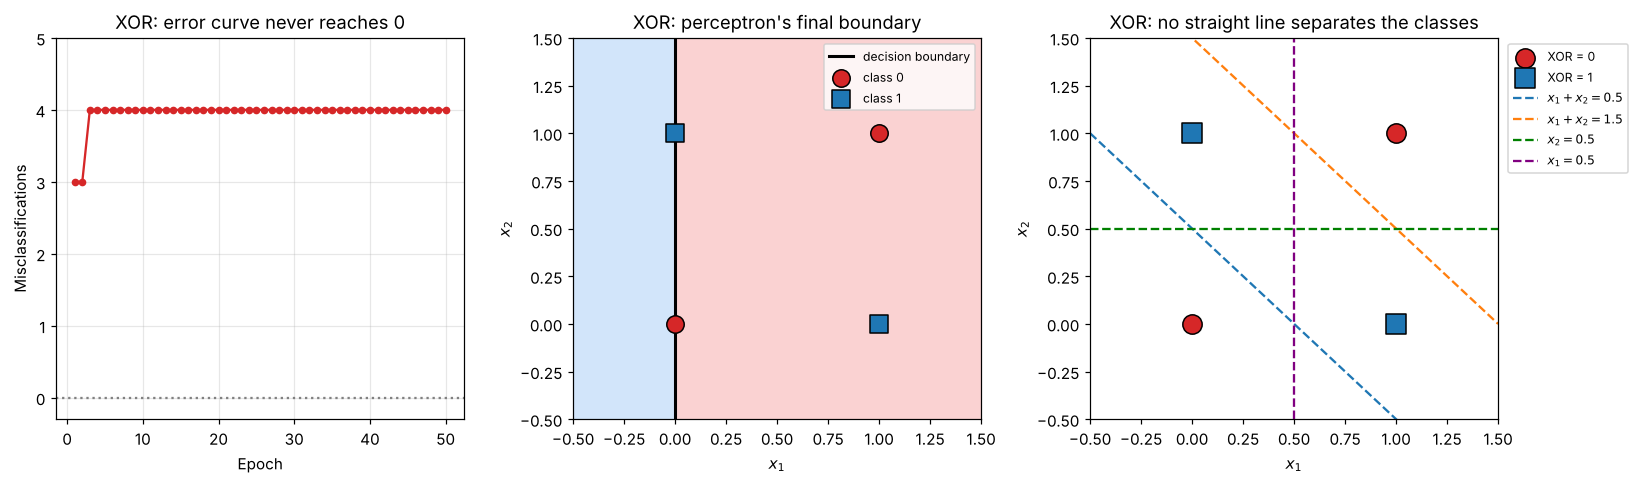

In [12]:
p_xor = Perceptron().fit(X, y_xor, epochs=50, lr=0.1)

print("errors per epoch (first 20):", p_xor.errors_[:20])
print("minimum errors in any epoch:", min(p_xor.errors_))
print("final predictions:", p_xor.predict(X), " target:", y_xor)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) error curve
axes[0].plot(range(1, 51), p_xor.errors_, "o-", color="tab:red", ms=4)
axes[0].axhline(0, color="gray", ls=":")
axes[0].set_ylim(-0.3, max(p_xor.errors_) + 1)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Misclassifications")
axes[0].set_title("XOR: error curve never reaches 0")
axes[0].grid(alpha=0.3)

# (b) the boundary the perceptron ends up with
plot_perceptron_boundary(p_xor, X, y_xor, axes[1], "XOR: perceptron's final boundary")

# (c) XOR points with candidate straight lines
ax = axes[2]
xs = np.linspace(-0.5, 1.5, 100)
for cls, marker, color in [(0, "o", "tab:red"), (1, "s", "tab:blue")]:
    ax.scatter(X[y_xor == cls, 0], X[y_xor == cls, 1], marker=marker, s=160, c=color,
               edgecolors="k", label=f"XOR = {cls}", zorder=3)
ax.plot(xs, -xs + 0.5, "--", label="$x_1 + x_2 = 0.5$")
ax.plot(xs, -xs + 1.5, "--", label="$x_1 + x_2 = 1.5$")
ax.axhline(0.5, color="green", ls="--", label="$x_2 = 0.5$")
ax.axvline(0.5, color="purple", ls="--", label="$x_1 = 0.5$")
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("XOR: no straight line separates the classes")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
plt.show()

**Explanation: failure in terms of linear separability**

A perceptron computes $\text{step}(w_1 x_1 + w_2 x_2 + b)$, so its decision boundary is the straight line $w_1 x_1 + w_2 x_2 + b = 0$.
It can only separate classes that are **linearly separable**.

For XOR we would need all four conditions to hold together:

| Point | Required | Condition |
|---|---|---|
| (0, 0) → 0 | $b < 0$ | |
| (1, 1) → 0 | $w_1 + w_2 + b < 0$ | |
| (0, 1) → 1 | $w_2 + b \ge 0$ | |
| (1, 0) → 1 | $w_1 + b \ge 0$ | |

Adding the last two lines: $w_1 + w_2 + 2b \ge 0$, so $w_1 + w_2 + b \ge -b > 0$ (because $b < 0$).
This contradicts $w_1 + w_2 + b < 0$. **No line can separate the XOR classes** (the two positive points lie on one diagonal, the two negative points on the other), which is exactly what the plot shows.

The **perceptron convergence theorem** guarantees convergence only for linearly separable data. For XOR the weights keep cycling, so the error per epoch never reaches zero.

# Task 03

2-layer MLP from scratch with NumPy (input → hidden sigmoid → output sigmoid), applied to XOR.

## Task 3.1

**Implement forward propagation and backpropagation (derive and code the gradients manually).**

**Notation.** $X \in \mathbb{R}^{N\times 2}$, $W_1 \in \mathbb{R}^{2\times h}$, $b_1 \in \mathbb{R}^{1\times h}$, $W_2 \in \mathbb{R}^{h\times 1}$, $b_2 \in \mathbb{R}$, and $\sigma(z) = \dfrac{1}{1+e^{-z}}$.

**Forward propagation**

$$Z_1 = XW_1 + b_1 \qquad A_1 = \sigma(Z_1) \qquad Z_2 = A_1 W_2 + b_2 \qquad \hat{Y} = A_2 = \sigma(Z_2)$$

**Loss (mean squared error)**

$$L = \frac{1}{N}\sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

**Useful derivative:** $\sigma'(z) = \sigma(z)\,(1-\sigma(z))$.

**Backpropagation (chain rule)**

Output layer:

$$\frac{\partial L}{\partial A_2} = \frac{2}{N}(A_2 - Y)$$

$$\delta_2 = \frac{\partial L}{\partial Z_2} = \frac{2}{N}(A_2 - Y) \odot A_2 \odot (1 - A_2)$$

$$\frac{\partial L}{\partial W_2} = A_1^{\top}\delta_2 \qquad\qquad \frac{\partial L}{\partial b_2} = \sum_{\text{rows}} \delta_2$$

Hidden layer (propagate the error back through $W_2$):

$$\delta_1 = \frac{\partial L}{\partial Z_1} = \left(\delta_2 W_2^{\top}\right) \odot A_1 \odot (1 - A_1)$$

$$\frac{\partial L}{\partial W_1} = X^{\top}\delta_1 \qquad\qquad \frac{\partial L}{\partial b_1} = \sum_{\text{rows}} \delta_1$$

**Gradient descent update** (learning rate $\eta$): $\ \theta \leftarrow \theta - \eta\,\dfrac{\partial L}{\partial \theta}$ for $\theta \in \{W_1, b_1, W_2, b_2\}$.

In [13]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


class MLP:
    def __init__(self, n_in=2, n_hidden=2, n_out=1, lr=0.5, seed=0):
        self.n_in, self.n_hidden, self.n_out = n_in, n_hidden, n_out
        self.lr = lr
        self.rng = np.random.default_rng(seed)
        self._init_params()

    def _init_params(self):
        # plain random initialization, N(0, 1)
        self.W1 = self.rng.standard_normal((self.n_in, self.n_hidden))
        self.b1 = np.zeros((1, self.n_hidden))
        self.W2 = self.rng.standard_normal((self.n_hidden, self.n_out))
        self.b2 = np.zeros((1, self.n_out))

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def loss(self, Y):
        return float(np.mean((self.A2 - Y) ** 2))

    def backward(self, Y):
        N = Y.shape[0]
        dZ2 = (2.0 / N) * (self.A2 - Y) * self.A2 * (1 - self.A2)
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dZ1 = (dZ2 @ self.W2.T) * self.A1 * (1 - self.A1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        return dW1, db1, dW2, db2

    def fit(self, X, Y, epochs=10000, tol=0.01, stop_early=False):
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float).reshape(-1, 1)
        self.loss_history_ = []
        self.converged_epoch_ = None      # first epoch where loss < tol
        for epoch in range(1, epochs + 1):
            self.forward(X)
            L = self.loss(Y)
            self.loss_history_.append(L)
            if L < tol and self.converged_epoch_ is None:
                self.converged_epoch_ = epoch
                if stop_early:
                    break
            dW1, db1, dW2, db2 = self.backward(Y)
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
        return self

    def predict_proba(self, X):
        return self.forward(np.asarray(X, dtype=float)).ravel()

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

**Gradient check.** To make sure the hand-derived gradients are correct, they are compared with numerical gradients
(central finite differences). The differences should be tiny (around $10^{-9}$ or smaller).

In [14]:
def numerical_grad(model, X, Y, param, eps=1e-6):
    grad = np.zeros_like(param)
    for idx in np.ndindex(param.shape):
        old = param[idx]
        param[idx] = old + eps
        model.forward(X)
        loss_plus = model.loss(Y)
        param[idx] = old - eps
        model.forward(X)
        loss_minus = model.loss(Y)
        param[idx] = old
        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
    return grad


Xc = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
Yc = np.array([0, 1, 1, 0], dtype=float).reshape(-1, 1)

check_model = MLP(n_hidden=3, seed=1)
check_model.forward(Xc)
analytic = check_model.backward(Yc)

for name, param, g in zip(["W1", "b1", "W2", "b2"],
                          [check_model.W1, check_model.b1, check_model.W2, check_model.b2],
                          analytic):
    num = numerical_grad(check_model, Xc, Yc, param)
    print(f"{name}: max |analytic - numerical| = {np.max(np.abs(g - num)):.2e}")

W1: max |analytic - numerical| = 3.13e-11
b1: max |analytic - numerical| = 1.64e-11
W2: max |analytic - numerical| = 2.06e-11
b2: max |analytic - numerical| = 2.04e-11


## Task 3.2

**Train the MLP on the XOR problem until the loss converges near zero (at least 2 hidden neurons).**

In [15]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
Y_xor = np.array([0, 1, 1, 0], dtype=float)

mlp = MLP(n_hidden=4, lr=1.0, seed=0)
mlp.fit(X_xor, Y_xor, epochs=10000, tol=0.01)

print(f"final loss (MSE): {mlp.loss_history_[-1]:.6f}")
print(f"loss first dropped below 0.01 at epoch: {mlp.converged_epoch_}")
print()
print(pd.DataFrame({
    "x1": X_xor[:, 0].astype(int),
    "x2": X_xor[:, 1].astype(int),
    "target": Y_xor.astype(int),
    "output (prob.)": mlp.predict_proba(X_xor).round(4),
    "prediction": mlp.predict(X_xor),
}).to_string(index=False))

final loss (MSE): 0.000340
loss first dropped below 0.01 at epoch: 1258

 x1  x2  target  output (prob.)  prediction
  0   0       0          0.0065           0
  0   1       1          0.9808           1
  1   0       1          0.9810           1
  1   1       0          0.0243           0


## Task 3.3

**Plot the loss (MSE) vs. epoch and the learned decision boundary.**

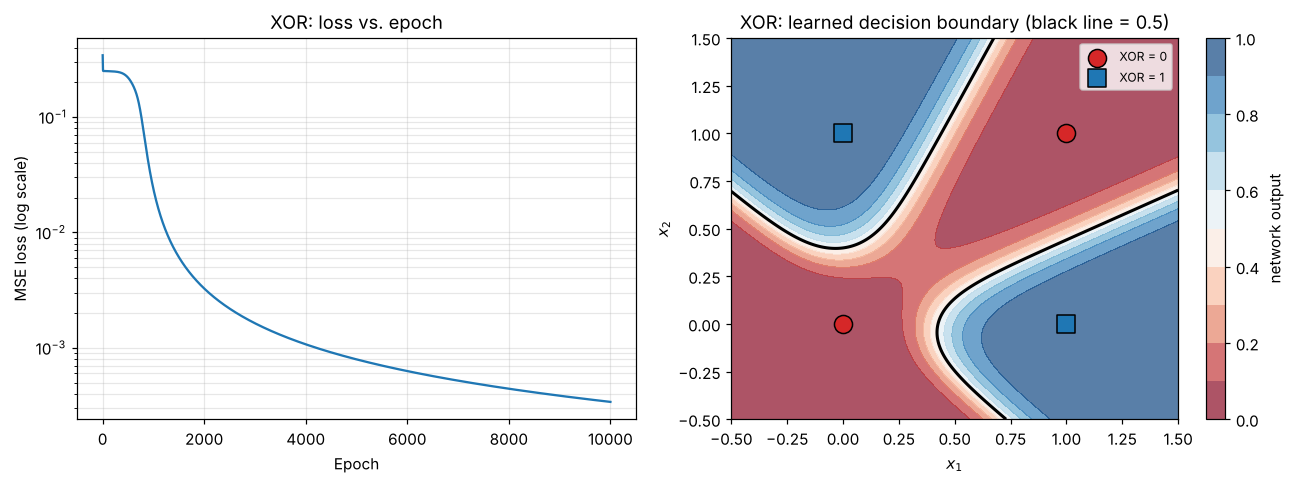

In [16]:
def plot_mlp_boundary(model, X, y, ax, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
    P = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cf = ax.contourf(xx, yy, P, levels=np.linspace(0, 1, 11), cmap="RdBu", alpha=0.7)
    ax.contour(xx, yy, P, levels=[0.5], colors="k", linewidths=2)
    for cls, marker, color in [(0, "o", "tab:red"), (1, "s", "tab:blue")]:
        ax.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=140, c=color,
                   edgecolors="k", label=f"XOR = {cls}", zorder=3)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    return cf


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(range(1, len(mlp.loss_history_) + 1), mlp.loss_history_)
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss (log scale)")
axes[0].set_title("XOR: loss vs. epoch")
axes[0].grid(alpha=0.3, which="both")

cf = plot_mlp_boundary(mlp, X_xor, Y_xor, axes[1], "XOR: learned decision boundary (black line = 0.5)")
fig.colorbar(cf, ax=axes[1], label="network output")

plt.tight_layout()
plt.show()

## Task 3.4

**Experiment: vary the number of hidden neurons (2, 4, 8) and the learning rate (0.01, 0.1, 1.0), and tabulate the epochs needed to converge.**

Convergence is defined as MSE $< 0.01$. Each run uses the same random seed and is capped at 50,000 epochs
(entries marked `> 50000` did not converge within the cap).

In [17]:
HIDDEN_SIZES = [2, 4, 8]
LEARNING_RATES = [0.01, 0.1, 1.0]
MAX_EPOCHS = 50000
TOL = 0.01
SEED = 0

epochs_table = {}
loss_table = {}
for h in HIDDEN_SIZES:
    epochs_table[h] = {}
    loss_table[h] = {}
    for lr in LEARNING_RATES:
        m = MLP(n_hidden=h, lr=lr, seed=SEED).fit(X_xor, Y_xor, epochs=MAX_EPOCHS, tol=TOL, stop_early=True)
        epochs_table[h][lr] = m.converged_epoch_ if m.converged_epoch_ is not None else f"> {MAX_EPOCHS}"
        loss_table[h][lr] = m.loss_history_[-1]

df_epochs = pd.DataFrame(epochs_table).T
df_epochs.index.name = "hidden neurons"
df_epochs.columns.name = "learning rate"

df_loss = pd.DataFrame(loss_table).T
df_loss.index.name = "hidden neurons"
df_loss.columns.name = "learning rate"

print("Epochs needed for MSE < 0.01:")
display(df_epochs)
print("Final loss when the run stopped:")
display(df_loss.style.format("{:.5f}"))

Epochs needed for MSE < 0.01:


learning rate,0.01,0.10,1.00
hidden neurons,,,
2,> 50000,21100,2114
4,> 50000,12504,1258
8,> 50000,6590,661


Final loss when the run stopped:


learning rate,0.010000,0.100000,1.000000
hidden neurons,,,
2,0.24997,0.01000,0.00997
4,0.21821,0.01000,0.00999
8,0.01956,0.01000,0.00997


**Observation:** a larger learning rate converges in far fewer epochs, while $\eta = 0.01$ is very slow for plain
full-batch gradient descent on this small problem. Adding more hidden neurons generally makes the problem easier
(more ways to carve out the XOR regions). Results for a single seed can vary, because XOR training can occasionally stall on a plateau for unlucky initializations.

# Task 04

Weight initialization schemes.

## Task 4.1

**Modify the MLP so the initialization scheme is a parameter: `init_method = "zero" | "random" | "xavier" | "he"`.**

| Scheme | Weights $W$ of a layer with `fan_in`, `fan_out` |
|---|---|
| `zero` | all zeros |
| `random` | $\mathcal{N}(0, 1)$ |
| `xavier` | $\mathcal{N}\!\left(0,\ \dfrac{2}{\text{fan\_in} + \text{fan\_out}}\right)$ (Glorot) |
| `he` | $\mathcal{N}\!\left(0,\ \dfrac{2}{\text{fan\_in}}\right)$ |

Biases are initialized to zero in every scheme. Only `_init_params` changes, so the new class reuses the forward pass, backpropagation and training loop of `MLP` from Task 03.

In [18]:
class MLPInit(MLP):
    def __init__(self, n_in=2, n_hidden=2, n_out=1, lr=0.5, seed=0, init_method="random"):
        assert init_method in ("zero", "random", "xavier", "he"), init_method
        self.init_method = init_method          # must be set before the parent calls _init_params
        super().__init__(n_in, n_hidden, n_out, lr, seed)

    def _weights(self, fan_in, fan_out):
        if self.init_method == "zero":
            return np.zeros((fan_in, fan_out))
        if self.init_method == "random":
            return self.rng.standard_normal((fan_in, fan_out))
        if self.init_method == "xavier":
            return self.rng.standard_normal((fan_in, fan_out)) * np.sqrt(2.0 / (fan_in + fan_out))
        if self.init_method == "he":
            return self.rng.standard_normal((fan_in, fan_out)) * np.sqrt(2.0 / fan_in)

    def _init_params(self):
        self.W1 = self._weights(self.n_in, self.n_hidden)
        self.b1 = np.zeros((1, self.n_hidden))
        self.W2 = self._weights(self.n_hidden, self.n_out)
        self.b2 = np.zeros((1, self.n_out))

## Task 4.2

**Train the same XOR MLP under each initialization scheme, keeping all other hyperparameters fixed.**

Fixed settings: 2 hidden neurons, learning rate 1.0, seed 0, 10,000 epochs, convergence when MSE $< 0.01$.

In [19]:
INIT_METHODS = ["zero", "random", "xavier", "he"]
T4_HIDDEN = 2
T4_LR = 1.0
T4_EPOCHS = 10000
T4_SEED = 0
TOL = 0.01

models = {}
for method in INIT_METHODS:
    models[method] = MLPInit(n_hidden=T4_HIDDEN, lr=T4_LR, seed=T4_SEED, init_method=method)
    models[method].fit(X_xor, Y_xor, epochs=T4_EPOCHS, tol=TOL)
    final = models[method].loss_history_[-1]
    print(f"{method:7s} final loss = {final:.6f}   predictions = {models[method].predict(X_xor)}")

zero    final loss = 0.250000   predictions = [1 1 1 1]


random  final loss = 0.000324   predictions = [0 1 1 0]


xavier  final loss = 0.000376   predictions = [0 1 1 0]


he      final loss = 0.000324   predictions = [0 1 1 0]


## Task 4.3

**For zero initialization, show and explain that the two hidden neurons learn identical weights (symmetry breaking failure).**

Each **column** of $W_1$ holds the incoming weights of one hidden neuron. We train a zero-initialized network for a few epochs and print $W_1$ after each stage.

In [20]:
demo = MLPInit(n_hidden=2, lr=T4_LR, seed=0, init_method="zero")

trained = 0
for target in [1, 2, 5, 50, 1000]:
    demo.fit(X_xor, Y_xor, epochs=target - trained, tol=TOL)
    trained = target
    print(f"--- hidden weight matrix W1 after {trained} epoch(s)  (column 0 = neuron 1, column 1 = neuron 2) ---")
    print(demo.W1)
    print("hidden biases b1:", demo.b1.ravel(), "   output weights W2:", demo.W2.ravel())
    print("neuron 1 == neuron 2 ?", np.allclose(demo.W1[:, 0], demo.W1[:, 1]),
          "| loss =", round(demo.loss_history_[-1], 6))
    print()

--- hidden weight matrix W1 after 1 epoch(s)  (column 0 = neuron 1, column 1 = neuron 2) ---
[[0. 0.]
 [0. 0.]]
hidden biases b1: [0. 0.]    output weights W2: [0. 0.]
neuron 1 == neuron 2 ? True | loss = 0.25

--- hidden weight matrix W1 after 2 epoch(s)  (column 0 = neuron 1, column 1 = neuron 2) ---
[[0. 0.]
 [0. 0.]]
hidden biases b1: [0. 0.]    output weights W2: [0. 0.]
neuron 1 == neuron 2 ? True | loss = 0.25

--- hidden weight matrix W1 after 5 epoch(s)  (column 0 = neuron 1, column 1 = neuron 2) ---
[[0. 0.]
 [0. 0.]]
hidden biases b1: [0. 0.]    output weights W2: [0. 0.]
neuron 1 == neuron 2 ? True | loss = 0.25

--- hidden weight matrix W1 after 50 epoch(s)  (column 0 = neuron 1, column 1 = neuron 2) ---
[[0. 0.]
 [0. 0.]]
hidden biases b1: [0. 0.]    output weights W2: [0. 0.]
neuron 1 == neuron 2 ? True | loss = 0.25

--- hidden weight matrix W1 after 1000 epoch(s)  (column 0 = neuron 1, column 1 = neuron 2) ---
[[0. 0.]
 [0. 0.]]
hidden biases b1: [0. 0.]    output weig

**What the output shows.** With zero initialization the two columns of $W_1$ are identical (both all zeros), and they never change: the loss stays at exactly $0.25$ and the network outputs $0.5$ for every input.

**Explanation (symmetry breaking failure)**

With all weights equal to zero, both hidden neurons receive the same input, compute the same activation
($\sigma(0) = 0.5$), and therefore get exactly the same gradient. Two things then happen:

- **Symmetry:** the two hidden neurons are identical, and every update treats them identically, so they can never become different from each other.
- **Zero gradient on XOR:** because $W_2 = 0$, we get $\delta_1 = (\delta_2 W_2^{\top}) \odot A_1 \odot (1-A_1) = 0$, so $W_1$ and $b_1$ receive no update. For $W_2$ and $b_2$, the gradient is proportional to $\sum_i (0.5 - y_i)$, which is exactly $0$ for XOR because two of the four targets are 1 and two are 0. So nothing moves at all and the network sits at this saddle point forever.

Even when the gradient is not zero, identical neurons receive identical updates and stay identical, so the hidden layer acts as **a single neuron** no matter how many hidden units we add, and one sigmoid neuron cannot represent XOR. The next cell demonstrates this with a constant (non-zero) initialization, where the weights do change but the two neurons remain identical.
Random initialization is therefore needed to **break the symmetry**.

In [21]:
# Supplementary demo: identical NON-zero start (every weight = 0.5), so gradients are non-zero
sym = MLPInit(n_hidden=2, lr=T4_LR, seed=0, init_method="zero")
sym.W1[:] = 0.5
sym.W2[:] = 0.5

trained = 0
for target in [1, 5, 100, 2000]:
    sym.fit(X_xor, Y_xor, epochs=target - trained, tol=TOL)
    trained = target
    print(f"--- W1 after {trained} epoch(s) (column 0 = neuron 1, column 1 = neuron 2) ---")
    print(sym.W1)
    print("neuron 1 == neuron 2 ?", np.allclose(sym.W1[:, 0], sym.W1[:, 1]),
          "| loss =", round(sym.loss_history_[-1], 6))
    print()

--- W1 after 1 epoch(s) (column 0 = neuron 1, column 1 = neuron 2) ---
[[0.4974 0.4974]
 [0.4974 0.4974]]
neuron 1 == neuron 2 ? True | loss = 0.271761

--- W1 after 5 epoch(s) (column 0 = neuron 1, column 1 = neuron 2) ---
[[0.4928 0.4928]
 [0.4928 0.4928]]
neuron 1 == neuron 2 ? True | loss = 0.253375

--- W1 after 100 epoch(s) (column 0 = neuron 1, column 1 = neuron 2) ---
[[0.5471 0.5471]
 [0.5471 0.5471]]
neuron 1 == neuron 2 ? True | loss = 0.24949

--- W1 after 2000 epoch(s) (column 0 = neuron 1, column 1 = neuron 2) ---
[[4.9841 4.9841]
 [4.9841 4.9841]]
neuron 1 == neuron 2 ? True | loss = 0.172154



## Task 4.4

**Plot the loss curves for all four initialization schemes on the same graph.**

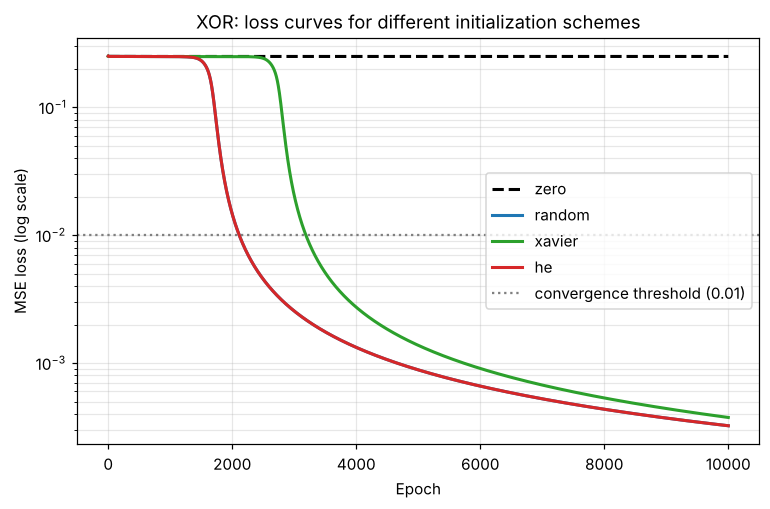

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.8))
styles = {"zero": "k--", "random": "tab:blue", "xavier": "tab:green", "he": "tab:red"}
for method in INIT_METHODS:
    h = models[method].loss_history_
    ax.plot(range(1, len(h) + 1), h, styles[method], lw=2, label=method)
ax.axhline(TOL, color="gray", ls=":", label=f"convergence threshold ({TOL})")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (log scale)")
ax.set_title("XOR: loss curves for different initialization schemes")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

## Task 4.5

**Tabulate epochs-to-convergence (and final loss after a fixed number of epochs) for each scheme.**

The first table uses the single run above (seed 0). Because initialization is random, the second table repeats the experiment
for 10 different seeds to show how reliable each scheme is.

In [23]:
rows = []
for method in INIT_METHODS:
    m = models[method]
    rows.append({
        "init_method": method,
        "epochs to converge (loss < 0.01)": m.converged_epoch_ if m.converged_epoch_ is not None else f"not converged in {T4_EPOCHS}",
        f"final loss after {T4_EPOCHS} epochs": round(m.loss_history_[-1], 6),
    })
print("Single run (seed 0):")
display(pd.DataFrame(rows).set_index("init_method"))

N_SEEDS = 10
rows = []
for method in INIT_METHODS:
    conv, final_losses = [], []
    for s in range(N_SEEDS):
        m = MLPInit(n_hidden=T4_HIDDEN, lr=T4_LR, seed=s, init_method=method)
        m.fit(X_xor, Y_xor, epochs=T4_EPOCHS, tol=TOL)
        final_losses.append(m.loss_history_[-1])
        if m.converged_epoch_ is not None:
            conv.append(m.converged_epoch_)
    rows.append({
        "init_method": method,
        f"converged runs (of {N_SEEDS})": len(conv),
        "median epochs (converged runs)": int(np.median(conv)) if conv else "-",
        "mean final loss": round(float(np.mean(final_losses)), 5),
    })
print(f"Robustness over {N_SEEDS} seeds:")
display(pd.DataFrame(rows).set_index("init_method"))

Single run (seed 0):


,epochs to converge (loss < 0.01),final loss after 10000 epochs
init_method,,
zero,not converged in 10000,0.250000
random,2114,0.000324
xavier,3189,0.000376
he,2114,0.000324


Robustness over 10 seeds:


,converged runs (of 10),median epochs (converged runs),mean final loss
init_method,,,
zero,0,-,0.25000
random,8,1100,0.02952
xavier,9,1306,0.01283
he,8,1100,0.02952


**Observations**

- `zero` never converges (0 of 10 seeds): the network is stuck at loss $0.25$ with identical, motionless hidden neurons.
- `random`, `xavier` and `he` all break the symmetry and solve XOR in most runs. Differences between them are small on this tiny network, and with only 10 seeds they should not be over-interpreted. Occasionally a run starts in a bad region and stalls on a plateau.
- `he` gives exactly the same numbers as `random` here: with 2 inputs and 2 hidden neurons, the He scale $\sqrt{2/\text{fan\_in}} = \sqrt{2/2} = 1$ for both layers, which is the same as plain $\mathcal{N}(0,1)$. Xavier uses a smaller scale ($\sqrt{2/(\text{fan\_in}+\text{fan\_out})}$), so its run differs.